In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("heart.csv")

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [6]:
df['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

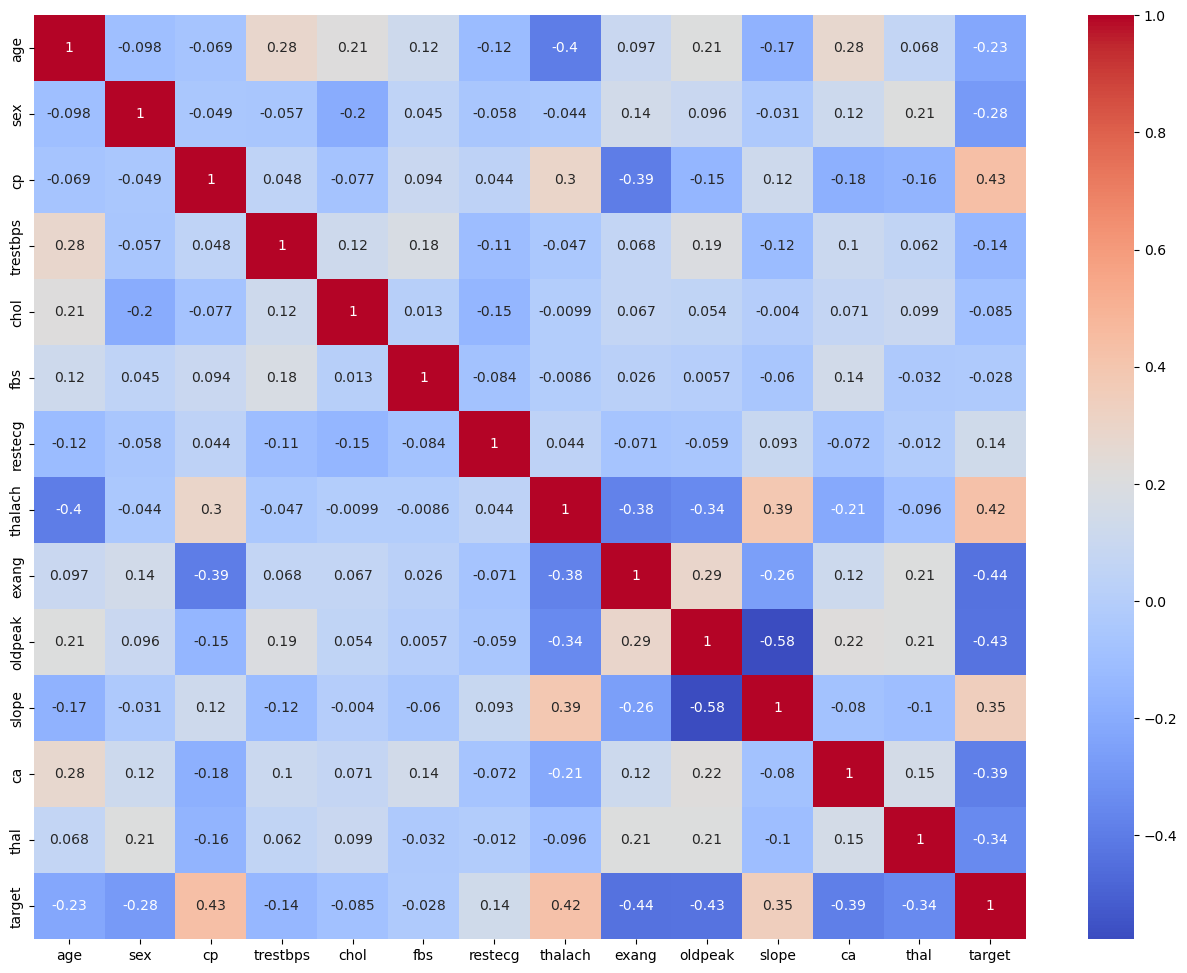

In [7]:
plt.figure(figsize=(16,12))
sns.heatmap(df.corr(),annot=True, cmap="coolwarm")
plt.show()

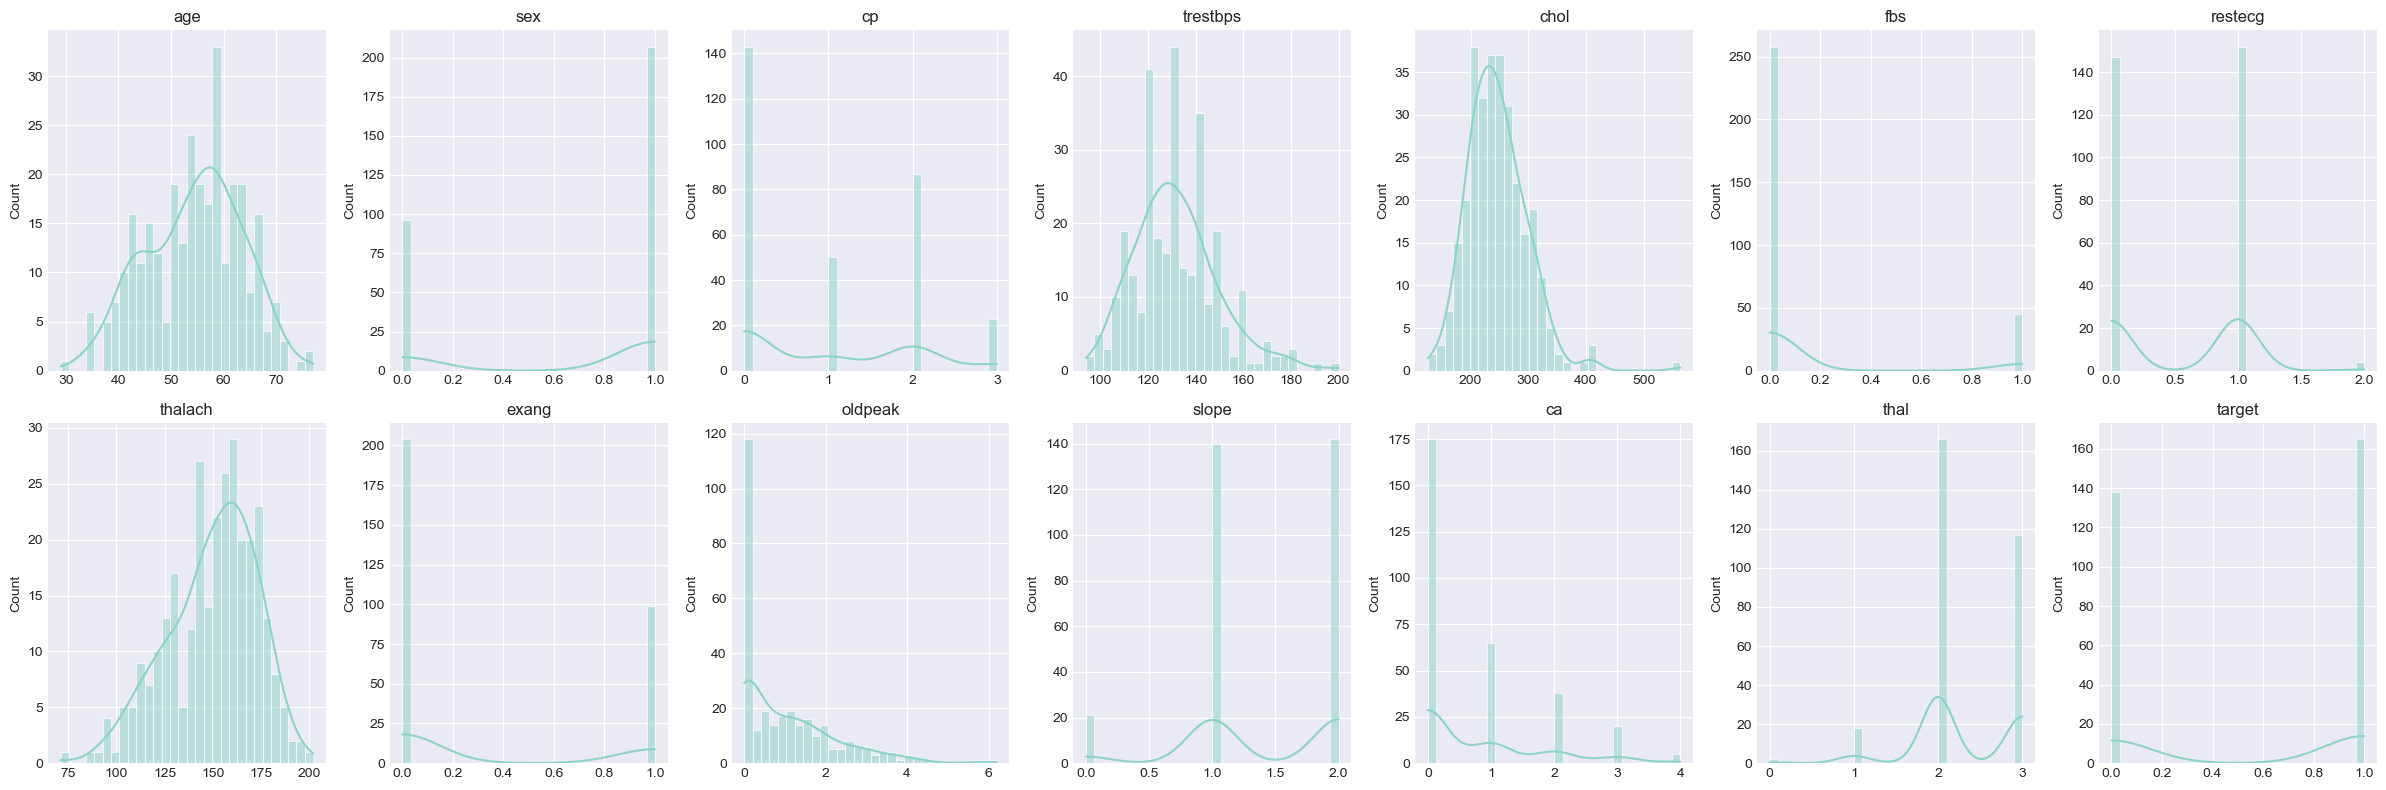

In [56]:
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 7, figsize=(24,8))  

for i, col in enumerate(df.columns[:14]):
    ax = axes[i // 7, i % 7]
    sns.histplot(x=df[col], kde=True, bins=30, ax=ax)
    ax.set_title(f"{col}")
    ax.set_xlabel("")
    ax.grid(True)

plt.tight_layout()
plt.show()

In [58]:
X = df.drop("target", axis=1)
y = df['target']

In [60]:
from sklearn.model_selection import train_test_split

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

In [68]:
def correlation_for_dropping(df, threshold):
    columns_to_drop = set()
    corr = df.corr()
    for i in range(len(corr.columns)):
        for j in range(i):
            if abs(corr.iloc[i, j]) > threshold:
                colname = corr.columns[i]
                columns_to_drop.add(colname)
    return columns_to_drop

In [70]:
correlation_for_dropping(X_train, 0.85)

set()

In [84]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
from sklearn.model_selection import GridSearchCV

In [78]:
gb = GradientBoostingClassifier()
gb.fit(X_train,y_train)

GradientBoostingClassifier()

In [88]:
y_pred = gb.predict(X_test)
print("Accuracy Score: ",accuracy_score(y_pred,y_test),"\n")
print("Classification Report \n",classification_report(y_pred,y_test))
print("Confusion Matrix \n",confusion_matrix(y_pred,y_test))

Accuracy Score:  0.7868852459016393 

Classification Report 
               precision    recall  f1-score   support

           0       0.82      0.74      0.78        31
           1       0.76      0.83      0.79        30

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.79      0.79      0.79        61

Confusion Matrix 
 [[23  8]
 [ 5 25]]


In [90]:
#hyperparamter tuning

In [92]:
parameters = {
        "loss" : ['log_loss', 'exponential'],
        "learning_rate" : [0.01, 0.05, 0.1],
        "n_estimators" : [100, 150, 180, 200],
        "max_depth" : [3,4,5],
        "subsample" : [0.8, 1.0]
}

In [94]:
grid = GridSearchCV(estimator=GradientBoostingClassifier(),param_grid=parameters, cv=5, n_jobs=-1,scoring="accuracy",verbose=3)

In [96]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


GridSearchCV(cv=5, estimator=GradientBoostingClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'loss': ['log_loss', 'exponential'],
                         'max_depth': [3, 4, 5],
                         'n_estimators': [100, 150, 180, 200],
                         'subsample': [0.8, 1.0]},
             scoring='accuracy', verbose=3)

In [98]:
grid.best_params_

{'learning_rate': 0.01,
 'loss': 'log_loss',
 'max_depth': 3,
 'n_estimators': 150,
 'subsample': 0.8}

In [100]:
y_pred = grid.predict(X_test)
print("Accuracy Score: ",accuracy_score(y_pred,y_test),"\n")
print("Classification Report \n",classification_report(y_pred,y_test))
print("Confusion Matrix \n",confusion_matrix(y_pred,y_test))

Accuracy Score:  0.8360655737704918 

Classification Report 
               precision    recall  f1-score   support

           0       0.86      0.80      0.83        30
           1       0.82      0.87      0.84        31

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61

Confusion Matrix 
 [[24  6]
 [ 4 27]]


In [110]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

In [104]:
params = {
    "n_estimators" : [100, 150, 200],
    "max_depth" : [3, 5, 7,],
    "max_features" : ["sqrt","log2",5, 8, 10],
}
grid = GridSearchCV(estimator=RandomForestClassifier(),param_grid=params,cv=5,n_jobs=-1,verbose=1,scoring="accuracy")
grid.fit(X_train,y_train)

Fitting 5 folds for each of 45 candidates, totalling 225 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 7],
                         'max_features': ['sqrt', 'log2', 5, 8, 10],
                         'n_estimators': [100, 150, 200]},
             scoring='accuracy', verbose=1)

In [105]:
grid.best_params_

{'max_depth': 3, 'max_features': 'sqrt', 'n_estimators': 100}

In [106]:
y_pred = grid.predict(X_test)
print("Accuracy Score: ",accuracy_score(y_pred,y_test),"\n")
print("Classification Report \n",classification_report(y_pred,y_test))
print("Confusion Matrix \n",confusion_matrix(y_pred,y_test))

Accuracy Score:  0.8032786885245902 

Classification Report 
               precision    recall  f1-score   support

           0       0.89      0.74      0.81        34
           1       0.73      0.89      0.80        27

    accuracy                           0.80        61
   macro avg       0.81      0.81      0.80        61
weighted avg       0.82      0.80      0.80        61

Confusion Matrix 
 [[25  9]
 [ 3 24]]


In [118]:
ada_params = {
    "n_estimators" : [50, 100, 150, 200],
    "learning_rate" : [0.01, 0.5, 0.1],
}
grid = GridSearchCV(estimator=AdaBoostClassifier(),param_grid=ada_params, cv=5,n_jobs=-1,verbose=1,scoring="accuracy")
grid.fit(X_train,y_train)
y_pred = grid.predict(X_test)

print(grid.best_params_)
print("Accuracy Score: ",accuracy_score(y_pred,y_test),"\n")
print("Classification Report \n",classification_report(y_pred,y_test))
print("Confusion Matrix \n",confusion_matrix(y_pred,y_test))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
{'learning_rate': 0.1, 'n_estimators': 50}
Accuracy Score:  0.7868852459016393 

Classification Report 
               precision    recall  f1-score   support

           0       0.82      0.74      0.78        31
           1       0.76      0.83      0.79        30

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.79      0.79      0.79        61

Confusion Matrix 
 [[23  8]
 [ 5 25]]


C:\Users\ahmet\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
